In [1]:
# Step 1:Import required libraries

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [2]:
# Step 2:load the California Housing dataset

# Load dataset as a pandas DataFrame
california = fetch_california_housing(as_frame=True)
df = california.frame

# Display first few rows
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Missing values per column:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Dataset Summary Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


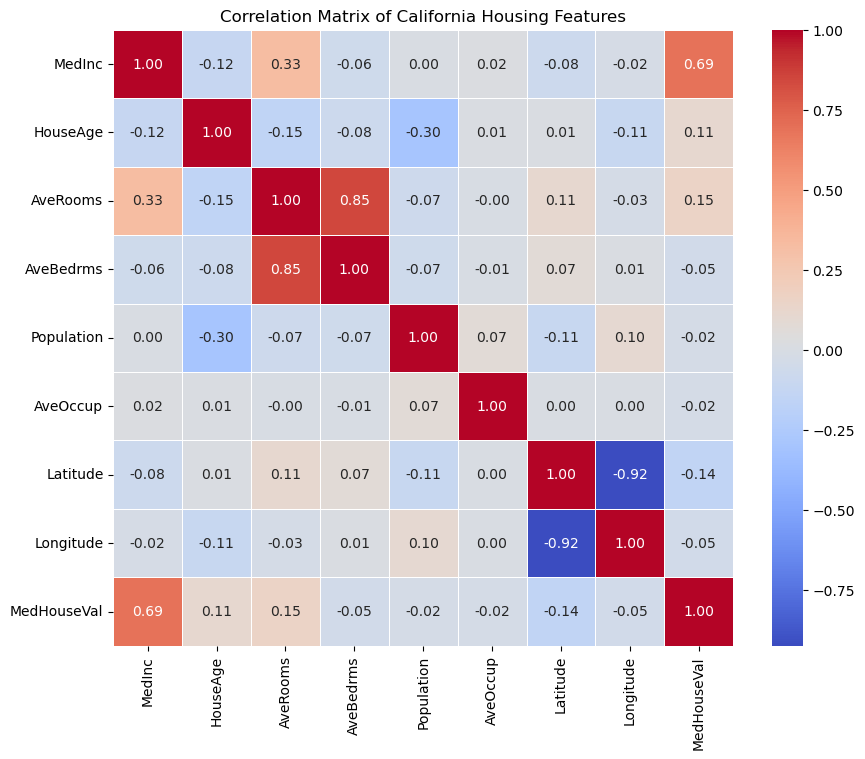

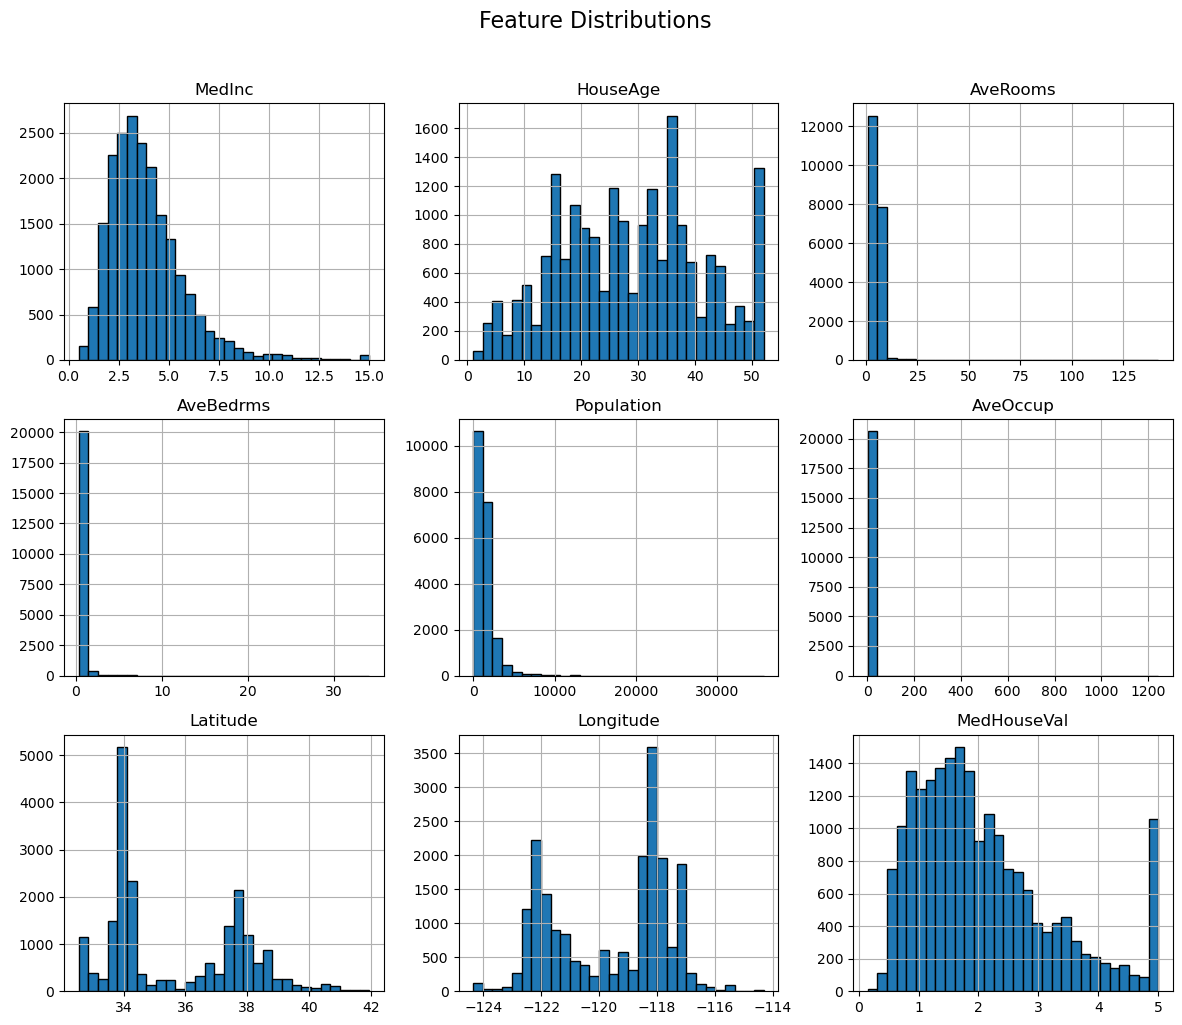

In [3]:
# Step 3: Perform EDA (Distributions, Correlations, Missing Values)

# 1. Check for missing values
print("Missing values per column:\n", df.isnull().sum())

# 2. Statistical summary
print("\nDataset Summary Statistics:")
display(df.describe())

# 3. Correlation matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of California Housing Features")
plt.show()

# 4. Feature distributions
df.hist(bins=30, figsize=(12, 10), edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [4]:
# Step 4: Select features and split data
X = df.drop(columns=["MedHouseVal"])  # Features
y = df["MedHouseVal"]  # Target (Median House Value)

# Split into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (16512, 8)
Testing features shape: (4128, 8)


In [5]:
# Step 5: Train LinearRegression and evaluate using MAE, RMSE, R²
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred = lr_model.predict(X_test)

# Metrics calculation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("--- Linear Regression Performance Metrics ---")
print(f"MAE  (Mean Absolute Error): {mae:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"R²   (R-Squared Score): {r2:.4f}")

--- Linear Regression Performance Metrics ---
MAE  (Mean Absolute Error): 0.5332
RMSE (Root Mean Squared Error): 0.7456
R²   (R-Squared Score): 0.5758


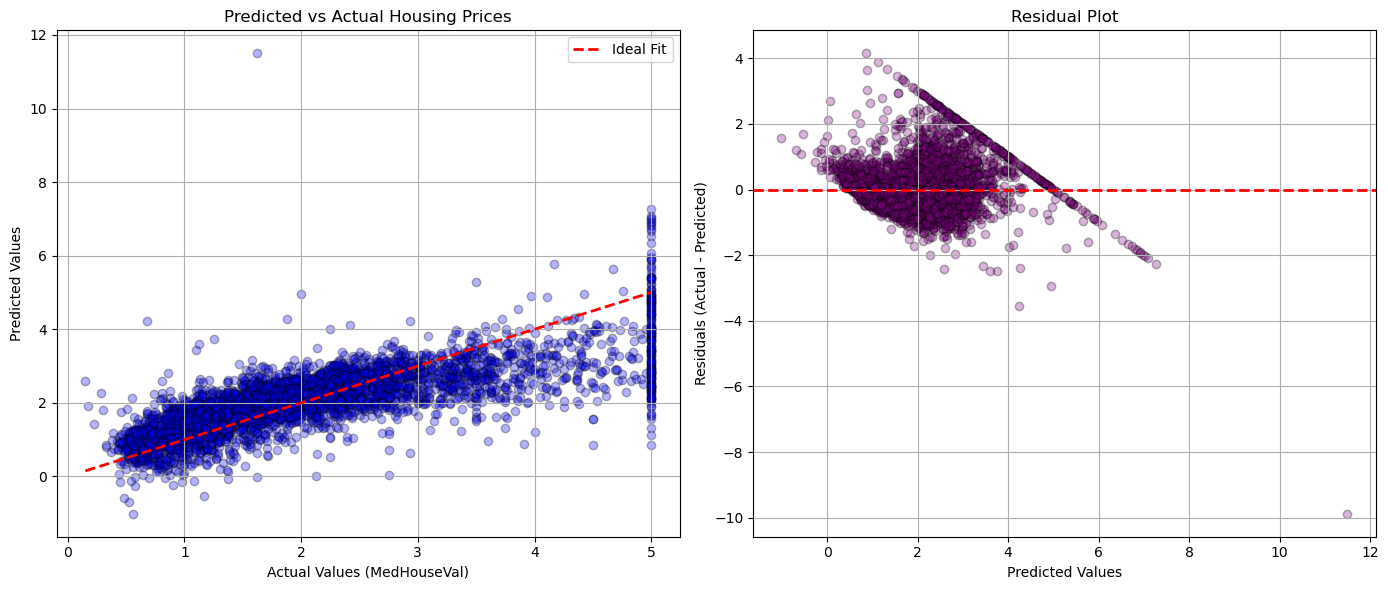

In [6]:
# Step 6: Plot predicted vs actual scatter plot and residuals

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Predicted vs Actual Scatter Plot
axes[0].scatter(y_test, y_pred, alpha=0.3, color="blue", edgecolors="k")
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Ideal Fit",
)
axes[0].set_xlabel("Actual Values (MedHouseVal)")
axes[0].set_ylabel("Predicted Values")
axes[0].set_title("Predicted vs Actual Housing Prices")
axes[0].legend()
axes[0].grid(True)

# 2. Residuals Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.3, color="purple", edgecolors="k")
axes[1].axhline(y=0, color="r", linestyle="--", lw=2)
axes[1].set_xlabel("Predicted Values")
axes[1].set_ylabel("Residuals (Actual - Predicted)")
axes[1].set_title("Residual Plot")
axes[1].grid(True)

plt.tight_layout()
plt.show()